# 3DGS Analysis

Baseline-style analysis notebook for `logs/3dgs/*` checkpoints.
It focuses on the legacy `.npz` artifacts but will also work with newer `.pth` files if they are present.

The notebook is intentionally conservative about memory use:

- analysis defaults to `cpu` to avoid CUDA OOM on large 50k-Gaussian checkpoints
- slice rendering is tiled in point batches instead of evaluating a full `1024 x 1024` slice at once
- checkpoint statistics are computed without loading whole rendered volumes unless you run the metrics cell


In [1]:
import json
import os
import importlib.util
import sys
from types import SimpleNamespace
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import torch
import yaml
from IPython.display import display
from skimage.metrics import structural_similarity

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

ROOT = Path('/mnt/intelpa-1/armin/containers/storage/main/research_3')
LOGS = ROOT / 'logs' / '3dgs'
ANALYSIS = LOGS / 'analysis'
ANALYSIS.mkdir(exist_ok=True)

with open(ROOT / 'configs' / '3dgs.yml') as f:
    DEFAULT_CFG = yaml.safe_load(f)

def resolve_path(path_like):
    path = Path(path_like)
    return path if path.is_absolute() else ROOT / path

VOLUME_PATH = resolve_path(DEFAULT_CFG['volume'])
gt_raw = tifffile.imread(VOLUME_PATH).astype(np.float32)
gt_min, gt_max = float(gt_raw.min()), float(gt_raw.max())
GT_VOL = (gt_raw - gt_min) / (gt_max - gt_min) if gt_max > gt_min else gt_raw
GT_VOL_T = torch.from_numpy(GT_VOL)
D, H, W = GT_VOL.shape
SLICE_IDXS = np.linspace(0, D - 1, 6, dtype=int)[1:-1].tolist()

# Use GPU for faster analysis. Set to 'cpu' if you have limited VRAM.
ANALYSIS_DEVICE = 'cuda'
DEVICE = 'cuda' if ANALYSIS_DEVICE == 'cuda' and torch.cuda.is_available() else 'cpu'
USE_KERNEL = False
MAX_POINTS_PER_BATCH = 16384 if DEVICE == 'cuda' else 65536
SAFE_CHUNK_N = 256 if DEVICE == 'cuda' else 1024

print(f'Root           : {ROOT}')
print(f'Logs           : {LOGS}')
print(f'Volume         : {VOLUME_PATH.name}')
print(f'GT shape       : {GT_VOL.shape}')
print(f'Analysis device: {DEVICE}')
print(f'Slice idxs     : {SLICE_IDXS}')
print(f'Point batch    : {MAX_POINTS_PER_BATCH}')
print(f'Gaussian chunk : {SAFE_CHUNK_N}')

Root           : /mnt/intelpa-1/armin/containers/storage/main/research_3
Logs           : /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs
Volume         : 10-2900-control-cell-05.oif-C0.v3dpbd.tif
GT shape       : (113, 1024, 1024)
Analysis device: cuda
Slice idxs     : [22, 44, 67, 89]
Point batch    : 16384
Gaussian chunk : 256


## 1 · Discover runs and parse logs / checkpoints

In [2]:
sys.path.insert(0, str(ROOT / 'src'))
spec = importlib.util.spec_from_file_location('gs3d_mod', ROOT / 'src' / '3dgs.py')
gs3d = importlib.util.module_from_spec(spec)
spec.loader.exec_module(gs3d)

def build_cfg(run_dir, device=DEVICE, use_kernel=USE_KERNEL):
    cfg = dict(DEFAULT_CFG)
    cfg_path = run_dir / 'config.json'
    if cfg_path.exists():
        cfg.update(json.loads(cfg_path.read_text()))
    cfg['volume'] = str(resolve_path(cfg.get('volume', DEFAULT_CFG['volume'])))
    swc_path = cfg.get('swc_path')
    cfg['swc_path'] = None if swc_path is None else str(resolve_path(swc_path))
    cfg['device'] = device
    cfg['use_kernel'] = bool(use_kernel and device == 'cuda')
    cfg.setdefault('chunk_n', DEFAULT_CFG.get('chunk_n', 1024))
    cfg.setdefault('scale_min_clamp', DEFAULT_CFG.get('scale_min_clamp', 1e-5))
    cfg.setdefault('mahal_max_clamp', DEFAULT_CFG.get('mahal_max_clamp', 20.0))
    cfg.setdefault('eval_samples', DEFAULT_CFG.get('eval_samples', 10000))
    cfg.setdefault('eval_full', True)
    cfg.setdefault('eval_full_max_voxels', 5_000_000)
    return SimpleNamespace(**cfg)

def metric_col(df):
    for key in ('psnr', 'fg_psnr'):
        if key in df.columns:
            return key
    return None

def checkpoint_kind(path):
    name = path.stem
    if name.startswith('best'):
        return 'best'
    if name.startswith('final'):
        return 'final'
    if name.startswith('ckpt_'):
        return 'checkpoint'
    return 'other'

def list_checkpoints(run_dir):
    paths = list(run_dir.glob('*.npz')) + list(run_dir.glob('*.pth'))
    return sorted(paths)

def pick_best_checkpoint(run_dir):
    for pattern in ('best.npz', 'best_*.pth', 'best.pth'):
        hits = sorted(run_dir.glob(pattern))
        if hits:
            return hits[0]
    return None

def load_ckpt_arrays(path):
    path = Path(path)
    if path.suffix == '.npz':
        with np.load(path) as d:
            return {
                'means': d['means'],
                'log_scales': d['log_scales'],
                'quats': d['quats'],
                'intensities': d['intensities'] if 'intensities' in d else d['opacities'],
            }
    state = torch.load(path, map_location='cpu')
    return {
        'means': state['means'].cpu().numpy(),
        'log_scales': state['log_scales'].cpu().numpy(),
        'quats': state['quats'].cpu().numpy(),
        'intensities': (state['intensities'] if 'intensities' in state else state['opacities']).cpu().numpy(),
    }

def load_cloud(ckpt_path, device=DEVICE, use_kernel=USE_KERNEL):
    cfg = build_cfg(ckpt_path.parent, device=device, use_kernel=use_kernel)
    gs3d.USE_CUDA_KERNEL = cfg.use_kernel
    aabb = gs3d.AABB.unit()
    dataset = gs3d.VolumeDataset(GT_VOL_T, aabb, cfg, swc_path=cfg.swc_path)
    gc = gs3d.GaussianCloud.load(ckpt_path, aabb, torch.device(cfg.device), cfg)
    return gc, dataset, cfg

RUN_DIRS = sorted([p for p in LOGS.iterdir() if p.is_dir() and (p / 'log.json').exists()])
assert RUN_DIRS, f'No 3DGS runs found under {LOGS}'

records = []
curves = {}
checkpoint_rows = []

for run_dir in RUN_DIRS:
    run = run_dir.name
    log_df = pd.DataFrame(json.loads((run_dir / 'log.json').read_text()))
    mcol = metric_col(log_df)
    if mcol is None:
        print(f'skipping {run}: no PSNR-like column found')
        continue

    psnr_vals = pd.to_numeric(log_df[mcol], errors='coerce')
    best_idx = int(psnr_vals.idxmax())
    cfg_json = json.loads((run_dir / 'config.json').read_text()) if (run_dir / 'config.json').exists() else {}
    ckpt_paths = list_checkpoints(run_dir)

    records.append({
        'run': run,
        'metric_col': mcol,
        'best_psnr': float(psnr_vals.iloc[best_idx]),
        'final_psnr': float(psnr_vals.dropna().iloc[-1]),
        'best_step': int(log_df.iloc[best_idx]['step']),
        'best_epoch': int(log_df.iloc[best_idx]['epoch']),
        'final_step': int(log_df.iloc[-1]['step']),
        'final_epoch': int(log_df.iloc[-1]['epoch']),
        'final_n_gauss': int(log_df.iloc[-1]['n_gauss']) if 'n_gauss' in log_df.columns else np.nan,
        'num_checkpoints': len(ckpt_paths),
        'swc_init': cfg_json.get('swc_init', DEFAULT_CFG.get('swc_init')),
        'densify_from_step': cfg_json.get('densify_from_step', DEFAULT_CFG.get('densify_from_step')),
        'densify_until_step': cfg_json.get('densify_until_step', DEFAULT_CFG.get('densify_until_step')),
    })
    curves[run] = {
        'step': pd.to_numeric(log_df['step'], errors='coerce').to_numpy(),
        'psnr': psnr_vals.to_numpy(),
        'n_gauss': pd.to_numeric(log_df['n_gauss'], errors='coerce').to_numpy() if 'n_gauss' in log_df.columns else None,
    }

    for order, ckpt_path in enumerate(ckpt_paths):
        arrs = load_ckpt_arrays(ckpt_path)
        scales = np.exp(arrs['log_scales'])
        inten = np.logaddexp(arrs['intensities'], 0.0)
        checkpoint_rows.append({
            'run': run,
            'order': order,
            'kind': checkpoint_kind(ckpt_path),
            'file': ckpt_path.name,
            'suffix': ckpt_path.suffix,
            'path': str(ckpt_path),
            'N': int(arrs['means'].shape[0]),
            'scale_mean': float(scales.mean()),
            'scale_max': float(scales.max()),
            'inten_mean': float(inten.mean()),
            'inten_p95': float(np.quantile(inten, 0.95)),
        })

summary = pd.DataFrame(records).sort_values('best_psnr', ascending=False).reset_index(drop=True)
ckpt_df = pd.DataFrame(checkpoint_rows)

summary.to_csv(ANALYSIS / 'summary.csv', index=False)
ckpt_df.to_csv(ANALYSIS / 'checkpoint_stats.csv', index=False)

display(summary.round(4))
print(f'Saved -> {ANALYSIS / "summary.csv"}')
print(f'Saved -> {ANALYSIS / "checkpoint_stats.csv"}')


,run,metric_col,best_psnr,final_psnr,best_step,best_epoch,final_step,final_epoch,final_n_gauss,num_checkpoints,swc_init,densify_from_step,densify_until_step
0,baseline,fg_psnr,44.6589,44.1748,11100,222,11600,232,50000,10,True,500,15000
1,ablation_a,psnr,42.3492,41.7549,23750,475,25000,500,22564,7,True,500,15000
2,run_10000_pat30,psnr,18.1455,17.9931,200,2,3200,32,1,2,True,500,15000
3,smoke,psnr,16.4190,16.4190,1,1,1,1,64,3,True,500,15000


Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/analysis/summary.csv
Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/analysis/checkpoint_stats.csv


## 2 · Training curves and Gaussian-count growth

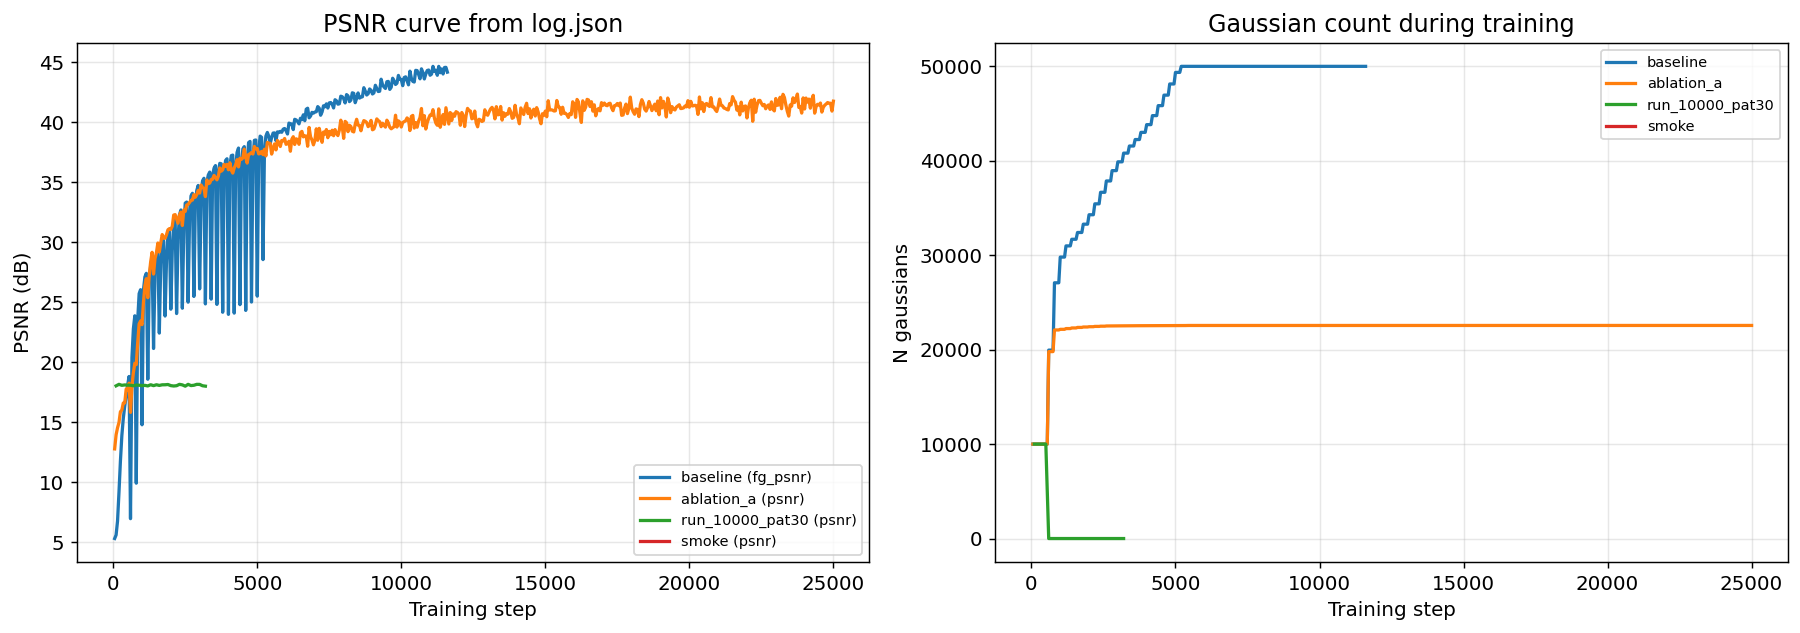

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/analysis/training_curves.png


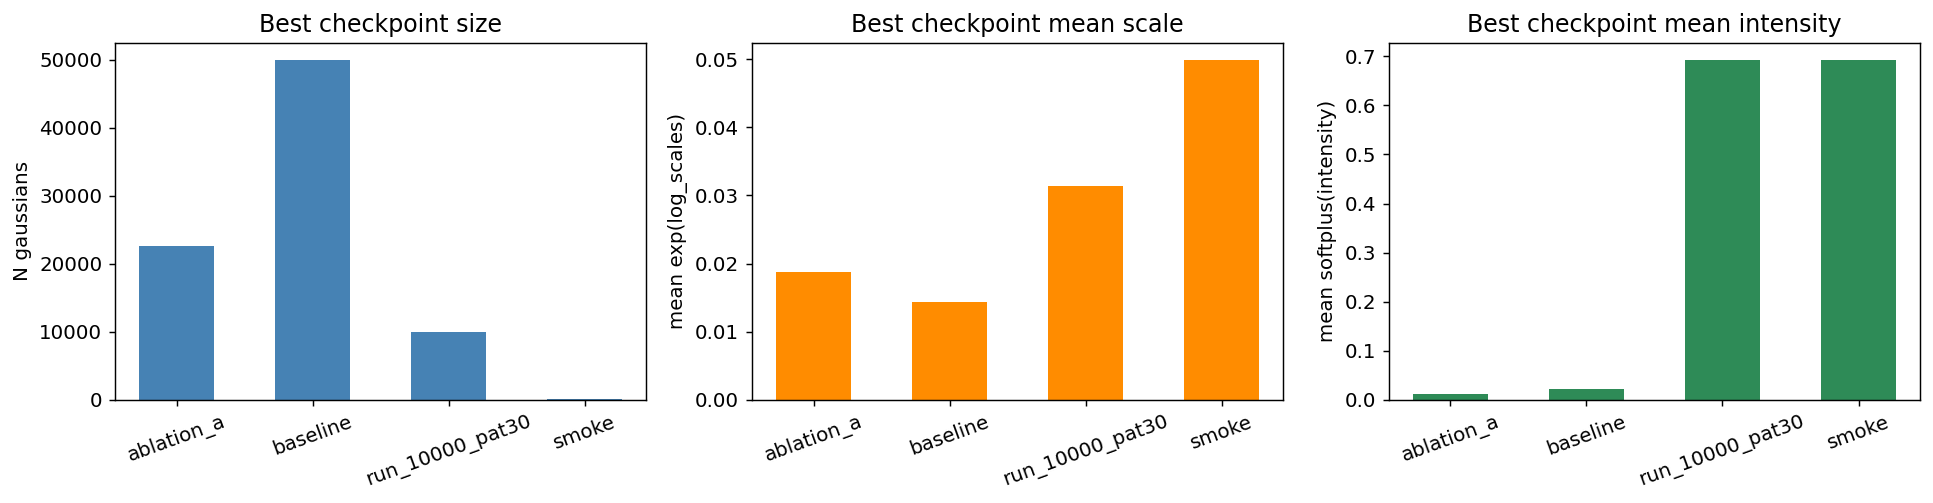

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/analysis/best_checkpoint_summary.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in summary.iterrows():
    run = row['run']
    curve = curves[run]
    label = f"{run} ({row['metric_col']})"
    axes[0].plot(curve['step'], curve['psnr'], linewidth=1.8, label=label)
    if curve['n_gauss'] is not None:
        axes[1].plot(curve['step'], curve['n_gauss'], linewidth=1.8, label=run)

axes[0].set_title('PSNR curve from log.json')
axes[0].set_xlabel('Training step')
axes[0].set_ylabel('PSNR (dB)')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_title('Gaussian count during training')
axes[1].set_xlabel('Training step')
axes[1].set_ylabel('N gaussians')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(ANALYSIS / 'training_curves.png', dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS / "training_curves.png"}')

best_rows = ckpt_df[ckpt_df['kind'] == 'best'].sort_values('run').reset_index(drop=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(best_rows['run'], best_rows['N'], color='steelblue', width=0.55)
axes[0].set_title('Best checkpoint size')
axes[0].set_ylabel('N gaussians')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(best_rows['run'], best_rows['scale_mean'], color='darkorange', width=0.55)
axes[1].set_title('Best checkpoint mean scale')
axes[1].set_ylabel('mean exp(log_scales)')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(best_rows['run'], best_rows['inten_mean'], color='seagreen', width=0.55)
axes[2].set_title('Best checkpoint mean intensity')
axes[2].set_ylabel('mean softplus(intensity)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(ANALYSIS / 'best_checkpoint_summary.png', dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {ANALYSIS / "best_checkpoint_summary.png"}')


## 3 · Full-volume metrics for the best checkpoints

This cell renders each best checkpoint slice-by-slice using tiled point batches, then caches
full-volume `PSNR` and mean-per-slice `SSIM` under `logs/3dgs/analysis/*_best_metrics.json`.
It is much slower on CPU, but it avoids the CUDA OOM seen with full-slice evaluation.


In [4]:
from tqdm import tqdm

def render_slice_safe(gc, dataset, z_idx, cfg, max_points_per_batch=MAX_POINTS_PER_BATCH, safe_chunk_n=2**20):
    H, W = dataset.H, dataset.W
    total = H * W
    rows_all = torch.arange(H, dtype=torch.long).repeat_interleave(W)
    cols_all = torch.arange(W, dtype=torch.long).tile(H)
    eff_chunk_n = int(min(getattr(cfg, 'chunk_n', safe_chunk_n), safe_chunk_n))
    pred_flat = np.empty(total, dtype=np.float32)

    with torch.no_grad():
        start = 0
        while start < total:
            end = min(start + max_points_per_batch, total)
            rows = rows_all[start:end]
            cols = cols_all[start:end]
            depth = torch.full((end - start,), int(z_idx), dtype=torch.long)
            pts = dataset._indices_to_pts(depth, rows, cols, gc.device)
            vals = gc.forward(pts, chunk_n=eff_chunk_n).clamp(0.0, 1.0)
            pred_flat[start:end] = vals.detach().cpu().numpy()
            start = end

    if gc.device.type == 'cuda':
        torch.cuda.empty_cache()
    return pred_flat.reshape(H, W)

def compute_slice_metrics(pred_vol, slice_indices=None):
    """Compute PSNR and per-slice SSIM for specified slices."""
    if slice_indices is None:
        slice_indices = [20, 40, 60, 80]
    
    # Filter to valid slice indices
    valid_slices = [z for z in slice_indices if z < len(GT_VOL)]
    
    psnrs = []
    ssims = []
    for z in valid_slices:
        mse = float(np.mean((pred_vol[z] - GT_VOL[z]) ** 2))
        psnr = float('inf') if mse == 0 else float(-10.0 * np.log10(mse))
        psnrs.append(psnr)
        
        ssim = float(structural_similarity(GT_VOL[z], pred_vol[z], data_range=1.0))
        ssims.append(ssim)
    
    return {
        'psnr_mean': float(np.mean(psnrs)),
        'ssim_mean': float(np.mean(ssims)),
        'slices': valid_slices,
    }

# Load only ablation_a checkpoint
ckpt_path = Path('/mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation_a/best.npz')
assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'

gc, dataset, cfg = load_cloud(ckpt_path)

# Reconstruct only 4 slices
slice_indices = [20, 40, 60, 80]
pred_vol = {}
for z in tqdm(slice_indices, desc='Slices'):
    if z < dataset.D:
        pred_vol[z] = render_slice_safe(gc, dataset, z, cfg)

metrics = compute_slice_metrics(pred_vol, slice_indices)

print(f'ablation_a: PSNR={metrics["psnr_mean"]:.2f} dB  SSIM={metrics["ssim_mean"]:.4f}')
print(f'Slices evaluated: {metrics["slices"]}')
display(metrics)

del gc, dataset, cfg, pred_vol
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Slices: 100%|██████████| 4/4 [02:36<00:00, 39.23s/it]


ablation_a: PSNR=35.20 dB  SSIM=0.9151
Slices evaluated: [20, 40, 60, 80]


{'psnr_mean': 35.19716679221861,
 'ssim_mean': 0.9151170430749056,
 'slices': [20, 40, 60, 80]}

## 4 · Slice comparison for the best checkpoints

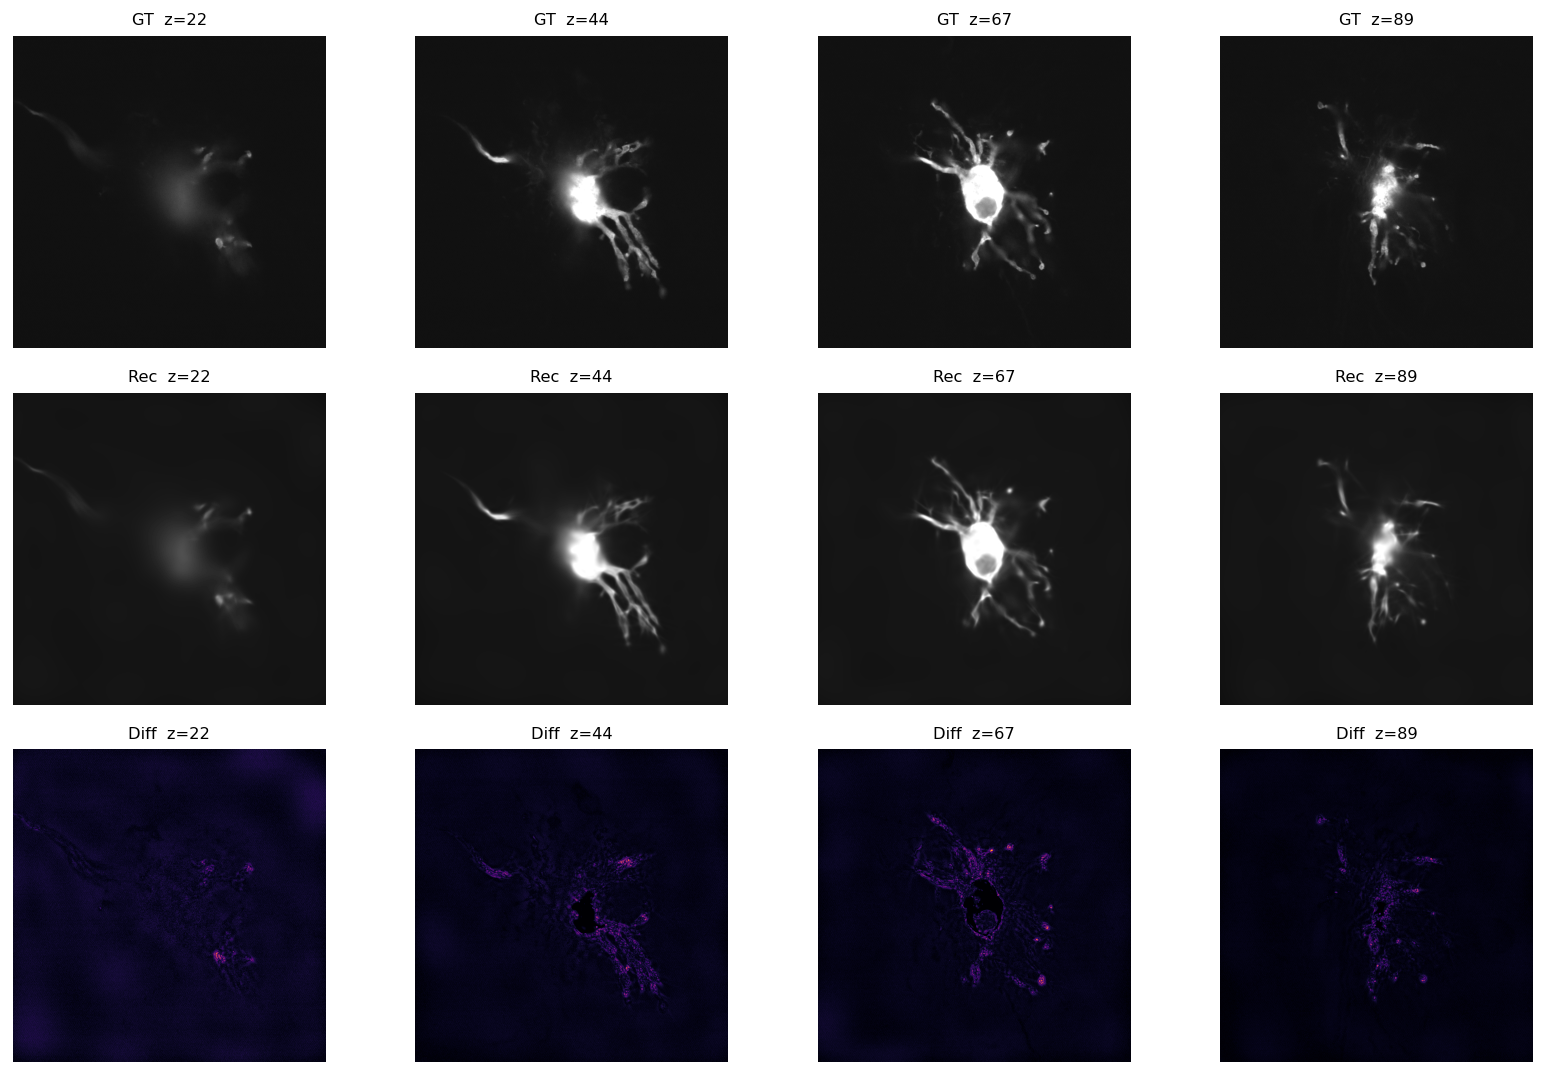

Saved -> /mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/analysis/ablation_a_best_slice_grid_rec_diff.png
Rendering cross-section at row 550 (shape D x W = 113 x 1024)


Row Recon: 100%|██████████| 113/113 [00:04<00:00, 24.01it/s]


ValueError: 'virdis_r' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwa

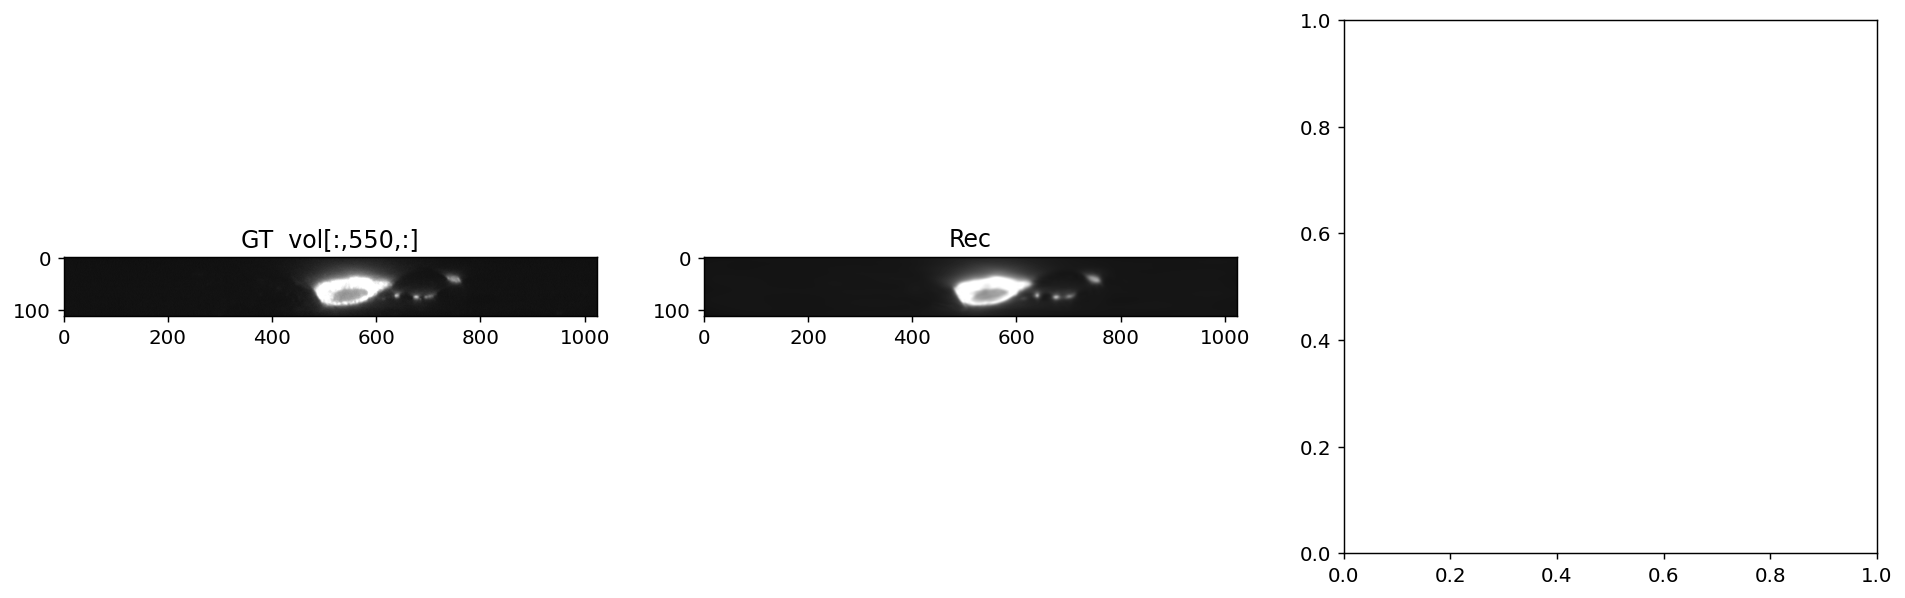

In [ ]:
# Render GT / Rec / Diff grid for a single best checkpoint (ablation_a)
RUNS_TO_RENDER = ['ablation_a']

n_runs = len(RUNS_TO_RENDER)
rows_per_run = 3
n_rows = n_runs * rows_per_run
n_cols = len(SLICE_IDXS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
if n_rows == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

from tqdm import tqdm
for run_idx, run in enumerate(RUNS_TO_RENDER):
    ckpt_path = pick_best_checkpoint(LOGS / run)
    if ckpt_path is None:
        print(f'No best checkpoint found for run: {run}')
        continue

    gc, dataset, cfg = load_cloud(ckpt_path)

    base_row = run_idx * rows_per_run
    for col, z in enumerate(SLICE_IDXS):
        # GT
        axes[base_row + 0, col].imshow(GT_VOL[z], cmap='gray', vmin=0, vmax=1)
        axes[base_row + 0, col].axis('off')
        if col == 0:
            axes[base_row + 0, col].set_ylabel(f'{run}\nGT', rotation=0, ha='right', va='center', labelpad=24)
        if run_idx == 0:
            axes[base_row + 0, col].set_title(f'GT  z={z}', fontsize=9)

        # Reconstruction
        pred = render_slice_safe(gc, dataset, int(z), cfg)
        axes[base_row + 1, col].imshow(pred, cmap='gray', vmin=0, vmax=1)
        axes[base_row + 1, col].axis('off')
        if col == 0:
            axes[base_row + 1, col].set_ylabel('Rec', rotation=0, ha='right', va='center', labelpad=24)
        if run_idx == 0:
            axes[base_row + 1, col].set_title(f'Rec  z={z}', fontsize=9)

        # Absolute difference
        diff = np.abs(GT_VOL[z] - pred)
        vmax = float(diff.max()) if float(diff.max()) > 0 else 1e-6
        axes[base_row + 2, col].imshow(diff, cmap='inferno', vmin=0, vmax=vmax)
        axes[base_row + 2, col].axis('off')
        if col == 0:
            axes[base_row + 2, col].set_ylabel('Diff', rotation=0, ha='right', va='center', labelpad=24)
        if run_idx == 0:
            axes[base_row + 2, col].set_title(f'Diff  z={z}', fontsize=9)

    del gc, dataset, cfg
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

plt.tight_layout()
out_path = ANALYSIS / f'{RUNS_TO_RENDER[0]}_best_slice_grid_rec_diff.png'
plt.savefig(out_path, dpi=250, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}')

# --- New: cross-section along rows (vol[:, ROW_IDX, :]) ---
ROW_IDX = 550
print(f'Rendering cross-section at row {ROW_IDX} (shape D x W = {D} x {W})')
ckpt_path = Path('/mnt/intelpa-1/armin/containers/storage/main/research_3/logs/3dgs/ablation_a/best.npz')
assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'

gc, dataset, cfg = load_cloud(ckpt_path)
assert ROW_IDX < dataset.H, f'ROW_IDX {ROW_IDX} out of range for H={dataset.H}'

D, W = dataset.D, dataset.W
pred_row = np.empty((D, W), dtype=np.float32)

with torch.no_grad():
    for z in tqdm(range(D), desc='Row Recon'):
        total = W
        start = 0
        vals_row = np.empty(total, dtype=np.float32)
        while start < total:
            end = min(start + MAX_POINTS_PER_BATCH, total)
            rows = torch.full((end - start,), ROW_IDX, dtype=torch.long, device=gc.device)
            cols = torch.arange(start, end, dtype=torch.long, device=gc.device)
            depth = torch.full((end - start,), z, dtype=torch.long, device=gc.device)
            pts = dataset._indices_to_pts(depth, rows, cols, gc.device)
            out = gc.forward(pts, chunk_n=getattr(cfg, 'chunk_n', SAFE_CHUNK_N)).clamp(0.0, 1.0)
            vals_row[start:end] = out.detach().cpu().numpy()
            start = end
        pred_row[z] = vals_row

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gt_row = GT_VOL[:, ROW_IDX, :]
diff_row = np.abs(gt_row - pred_row)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(gt_row, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'GT  vol[:,{ROW_IDX},:]')
axes[1].imshow(pred_row, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Rec')
vmax = float(diff_row.max()) if float(diff_row.max()) > 0 else 1e-6
axes[2].imshow(diff_row, cmap='viridis_r', vmin=0, vmax=vmax)
axes[2].set_title('Diff')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
row_out = ANALYSIS / f'{RUNS_TO_RENDER[0]}_row{ROW_IDX}_rec_diff.png'
plt.savefig(row_out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved -> {row_out}')

display(ckpt_df[ckpt_df['kind'].isin(['best', 'final'])].sort_values(['run', 'kind', 'file']).reset_index(drop=True).round(4))
